In [1]:
"""

InfoGAN
Information Maximizing GAN (Chen et al., 2016)

"""

'\n\nInfoGAN \nInformation Maximizing GAN (Chen et al., 2016)\n\n'

In [2]:
import os

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torch.nn.utils.spectral_norm as sn

from tqdm import tqdm
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("spandan2/cats-faces-64x64-for-generative-models")

print("Path to dataset files:", path)

100%|██████████| 96.0M/96.0M [00:00<00:00, 213MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/spandan2/cats-faces-64x64-for-generative-models/versions/1


In [4]:
# Optimize convolution algorithms for fixed input sizes to boost training speed
torch.backends.cudnn.benchmark = True

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

total_step = 5000
batch_size = 64
latent_size = 100
class_size = 1 # I don't know the learning about label is meaningful cuz label = 1 (only cats.)
code_size = 5

lr = 0.0002
lambda_categorical = 1.0
lambda_continuous = 0.1

In [6]:
PRINT_INTERVAL = 25
SAMPLE_INTERVAL = 200
CHECKPOINT_INTERVAL = 1000

sample_dir = "./samples"
checkpoint_dir = "./checkpoints"
os.makedirs(sample_dir, exist_ok=True)
os.makedirs(checkpoint_dir, exist_ok=True)

image shape: torch.Size([64, 3, 32, 32])
dataset size: 15747


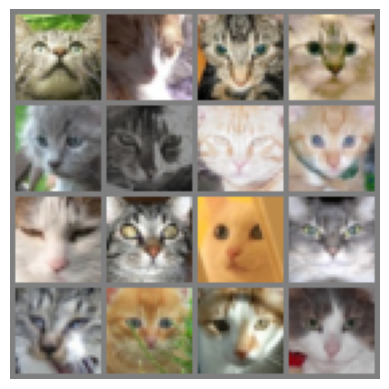

In [7]:
class ImageDataLoader:
    def __init__(self, dataloader):
        self.dataloader = dataloader
        self.iterator = iter(dataloader)

    def __iter__(self):
        return self

    def __next__(self):
        try:
            return next(self.iterator)[0]
        except StopIteration:
            self.iterator = iter(self.dataloader)
            return next(self.iterator)[0]

transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

dataset = datasets.ImageFolder(root=path, transform=transform)
data_loader = DataLoader(
    dataset=dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True
)
train_loader = ImageDataLoader(data_loader)

# Test
images = next(iter(train_loader))
print(f"image shape: {images.shape}")
print(f"dataset size: {len(dataset) // 2}")

images = torchvision.utils.make_grid(images[:16], nrow=4)
images = (images + 1) / 2 # [-1, 1] -> [0, 1]
plt.imshow(images.permute(1, 2, 0))
plt.axis("off")
plt.show()

In [8]:
#################### Generator ####################

class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(latent_size + class_size + code_size, 256 * 4 * 4), # 100 + 1 + 5
            nn.Unflatten(1, (256, 4, 4)),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            UpBlock(256, 128), # (B, 256, 4, 4)  -> (B, 128, 8, 8)
            UpBlock(128, 64),  # (B, 128, 8, 8)  -> (B, 64, 16, 16)
            UpBlock(64, 32),   # (B, 64, 16, 16) -> (B, 32, 32, 32)

            nn.Conv2d(32, 3, 3, 1, 1), # (B, 3, 32, 32)
            nn.Tanh()
        )

        self.network.apply(init_weights)

    def forward(self, z, label, code):
        return self.network(torch.cat((z, label, code), -1))

#################### UpBlock ####################

class UpBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.up = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear'),
            nn.Conv2d(in_channels, out_channels, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2)
        )

    def forward(self, x):
        return self.up(x)

In [9]:
#################### Discriminator ####################

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            DownBlock(3, 64), # 32 -> 16
            DownBlock(64, 128),                # 16 -> 8
            DownBlock(128, 256),               # 8 -> 4
            nn.Flatten()
        )

        self.adversarial_layer = nn.Linear(256 * 4 * 4, 1)
        self.auxiliary_layer = nn.Linear(256 * 4 * 4, class_size) # classes = 1
        self.latent_layer = nn.Linear(256 * 4 * 4, code_size) # code_size = 5

        self.network.apply(init_weights)

    def forward(self, image):
        out = self.network(image)
        adv_out = self.adversarial_layer(out)
        aux_out = self.auxiliary_layer(out)
        latent_out = self.latent_layer(out)
        return adv_out, aux_out, latent_out

#################### DownBlock ####################

class DownBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.down = nn.Sequential(
            sn(nn.Conv2d(in_channels, out_channels, 3, 2, 1)),
            # nn.BatchNorm2d(out_channels) if use_norm else nn.Identity(),
            nn.LeakyReLU(0.2)
        )

    def forward(self, x):
        return self.down(x)

In [10]:
def init_weights(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
        # spectral_norm이 적용된 레이어는 건너뜀
        if hasattr(m, 'weight_orig'):
            return
        nn.init.normal_(m.weight, 0.0, 0.02)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.normal_(m.weight, 1.0, 0.02)
        nn.init.zeros_(m.bias)

In [11]:
def visualize_sample(fixed_z, fixed_label, fixed_code, step):
    generator.eval()
    with torch.no_grad():
        fake_images = generator(fixed_z, fixed_label, fixed_code).cpu()
        fake_images = (fake_images + 1) / 2  # [-1, 1] -> [0, 1]

        grid = torchvision.utils.make_grid(fake_images, nrow=8)
        plt.figure(figsize=(16, 4))
        plt.imshow(grid.permute(1, 2, 0))
        plt.axis("off")
        plt.tight_layout()
        plt.show()

        torchvision.utils.save_image(
            fake_images,
            f"{sample_dir}/step_{step:03d}.png",
            nrow=8
        )
    generator.train()

def save_checkpoint(step):
    torch.save({
        "step": step,
        "generator": generator.state_dict(),
        "discriminator": discriminator.state_dict(),
        "optimizer_G": optimizer_G.state_dict(),
        "optimizer_D": optimizer_D.state_dict(),
        "optimizer_info": optimizer_info.state_dict(),
    }, f"{checkpoint_dir}/gan_step_{step:03d}.pth")

def load_checkpoint(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)

    generator.load_state_dict(checkpoint["generator"])
    discriminator.load_state_dict(checkpoint["discriminator"])
    optimizer_G.load_state_dict(checkpoint["optimizer_G"])
    optimizer_D.load_state_dict(checkpoint["optimizer_D"])
    optimizer_info.load_state_dict(checkpoint["optimizer_info"])
    start_step = checkpoint["step"]
    print(f"Loaded checkpoint: {checkpoint_path} (step {start_step})")
    return start_step

In [12]:
def to_onehot(y, num_columns):
    return F.one_hot(y, num_classes=num_columns).float()

In [13]:
generator = Generator().to(device)
discriminator = Discriminator().to(device)

adversarial_criterion = nn.BCEWithLogitsLoss()
categorical_criterion = nn.CrossEntropyLoss()
continuous_criterion = nn.MSELoss()

optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.99))
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.99))
optimizer_info = optim.Adam(
    list(generator.parameters()) + list(discriminator.parameters()),
    lr=lr, betas=(0.5, 0.99)
)

In [14]:
# if pretrained
# path = "./checkpoints/gan_epoch_1000.pth"
# start_step = load_checkpoint(path)
start_step = 0

D_loss: 1.0906  G_loss: 0.9701  D(x): 0.507  D(G(z)): -0.298  Info_loss: 0.0051:   4%|▍         | 199/5000 [00:16<05:14, 15.25it/s]

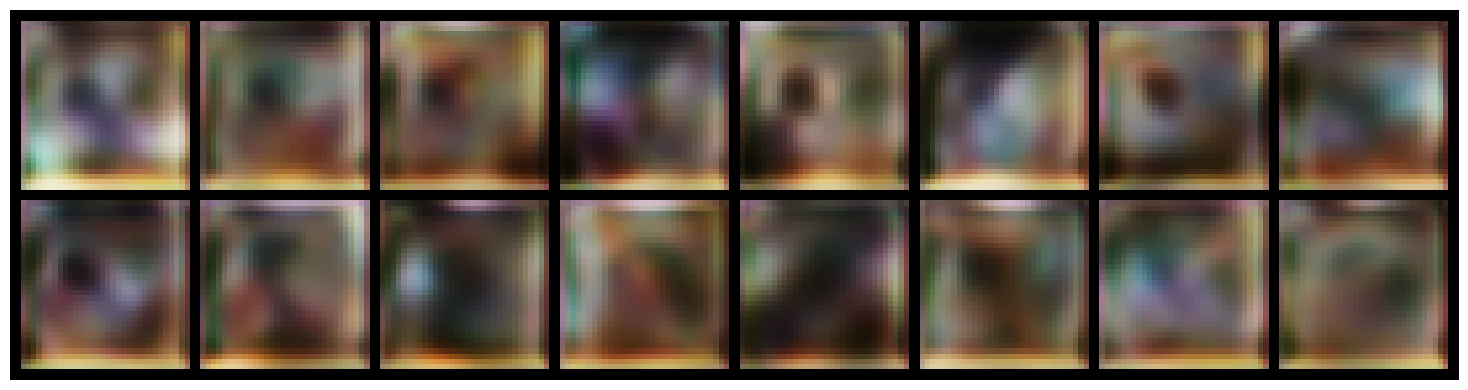

D_loss: 1.3328  G_loss: 0.7469  D(x): 0.186  D(G(z)): 0.011  Info_loss: 0.0037:   8%|▊         | 399/5000 [00:29<04:40, 16.38it/s] 

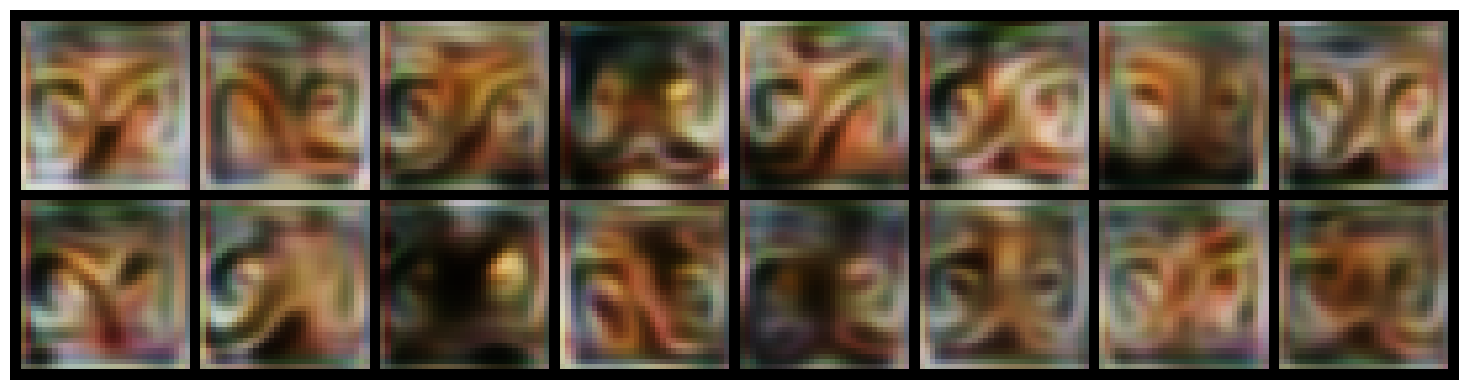

D_loss: 1.1900  G_loss: 0.7845  D(x): 0.322  D(G(z)): -0.182  Info_loss: 0.0029:  12%|█▏        | 599/5000 [00:43<04:28, 16.38it/s]

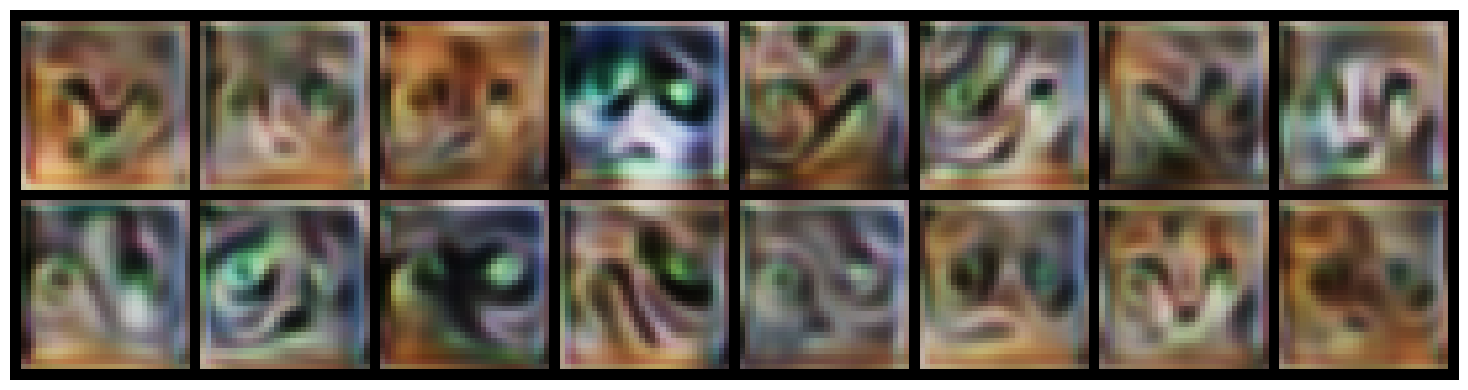

D_loss: 1.2498  G_loss: 0.8637  D(x): 0.173  D(G(z)): -0.180  Info_loss: 0.0018:  16%|█▌        | 799/5000 [00:56<04:18, 16.26it/s]

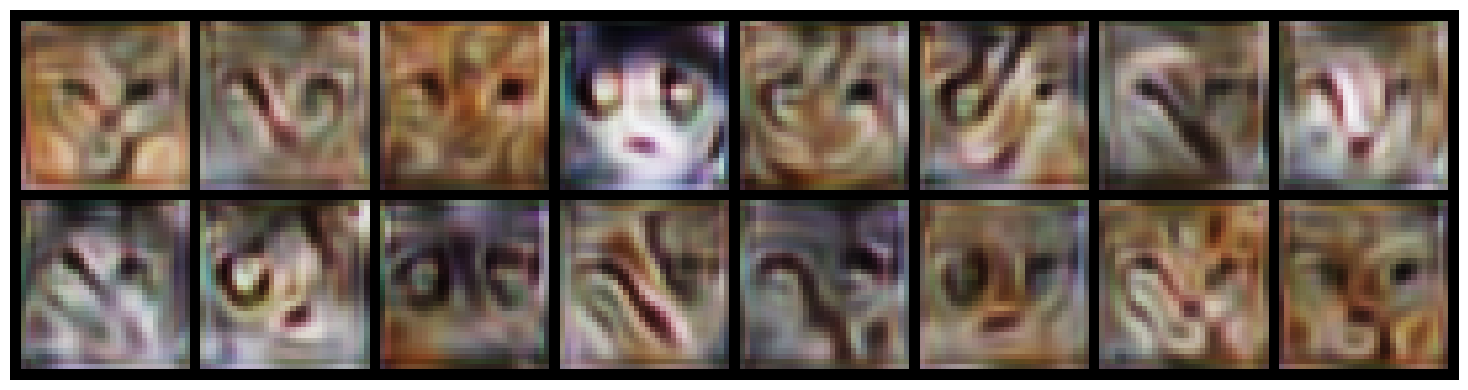

D_loss: 1.2652  G_loss: 0.8332  D(x): 0.150  D(G(z)): -0.143  Info_loss: 0.0019:  20%|█▉        | 999/5000 [01:10<04:09, 16.03it/s]

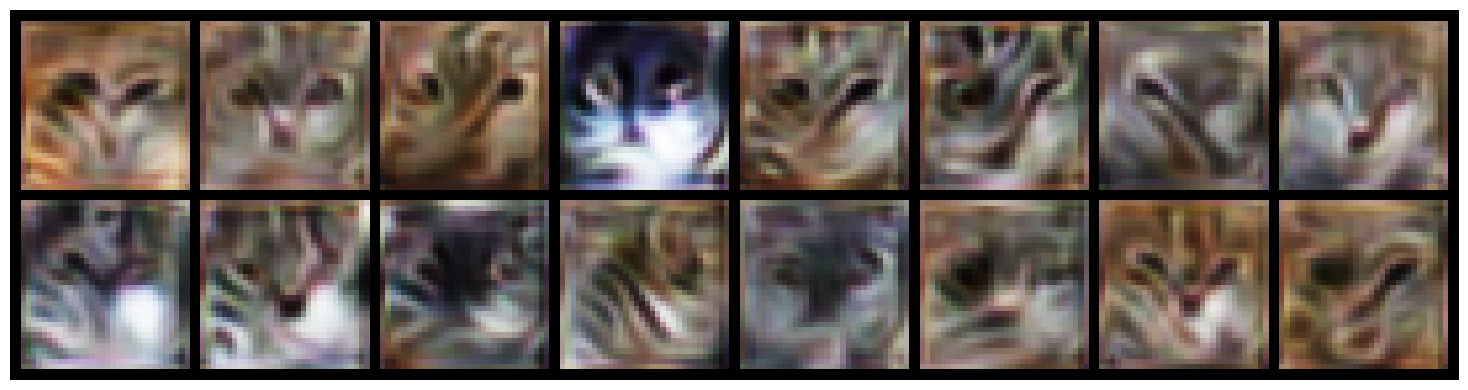

D_loss: 1.3054  G_loss: 0.8304  D(x): 0.259  D(G(z)): 0.031  Info_loss: 0.0014:  24%|██▍       | 1199/5000 [01:23<03:54, 16.23it/s] 

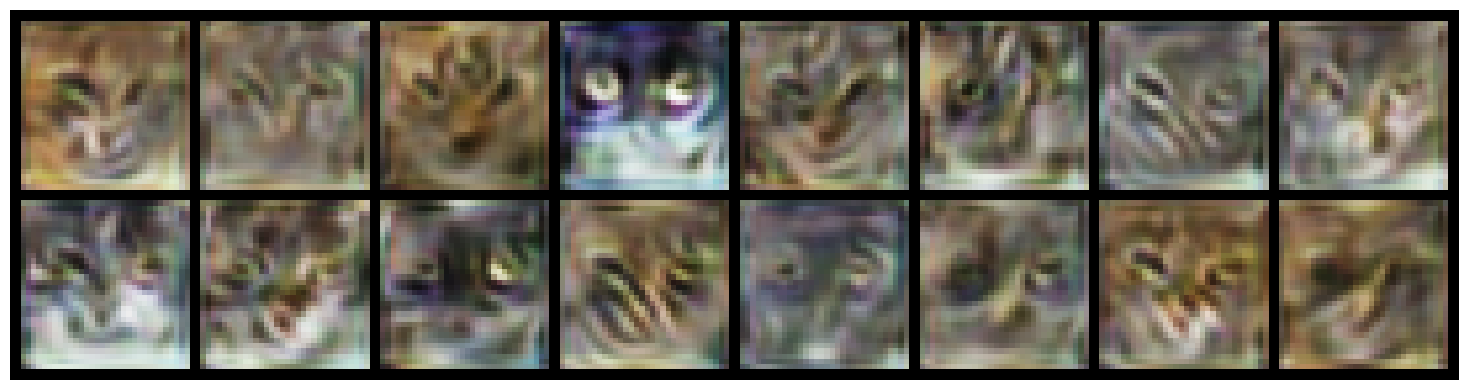

D_loss: 1.2885  G_loss: 0.7953  D(x): 0.165  D(G(z)): -0.066  Info_loss: 0.0021:  28%|██▊       | 1399/5000 [01:36<04:31, 13.25it/s]

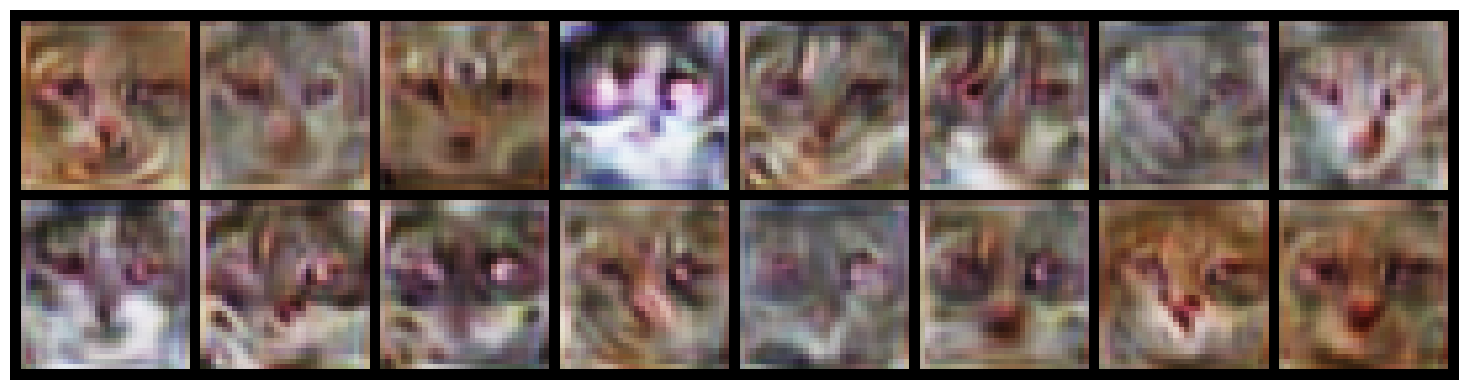

D_loss: 1.4125  G_loss: 0.7755  D(x): -0.038  D(G(z)): -0.019  Info_loss: 0.0008:  32%|███▏      | 1599/5000 [01:49<04:21, 12.99it/s]

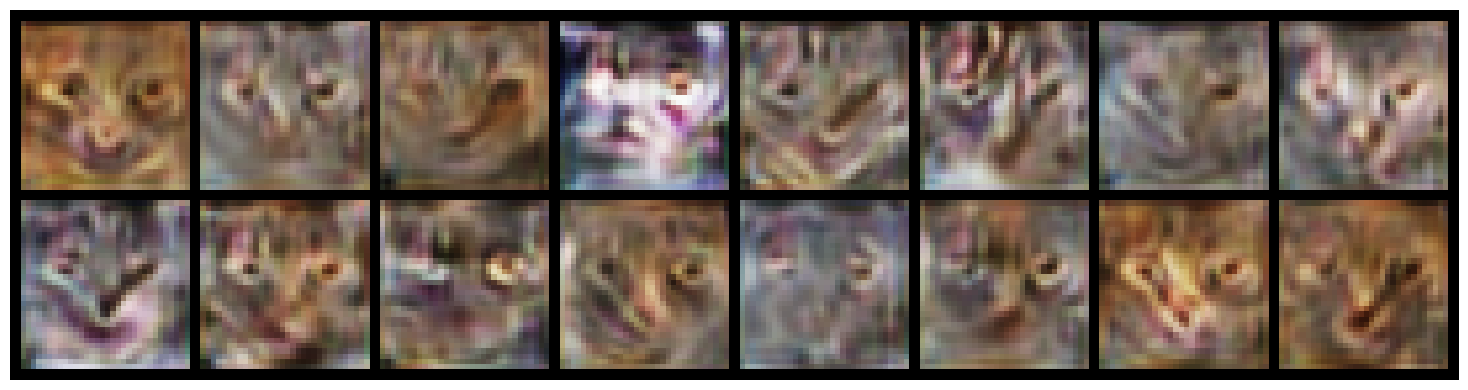

D_loss: 1.2982  G_loss: 0.8411  D(x): -0.021  D(G(z)): -0.279  Info_loss: 0.0014:  36%|███▌      | 1799/5000 [02:03<04:08, 12.87it/s]

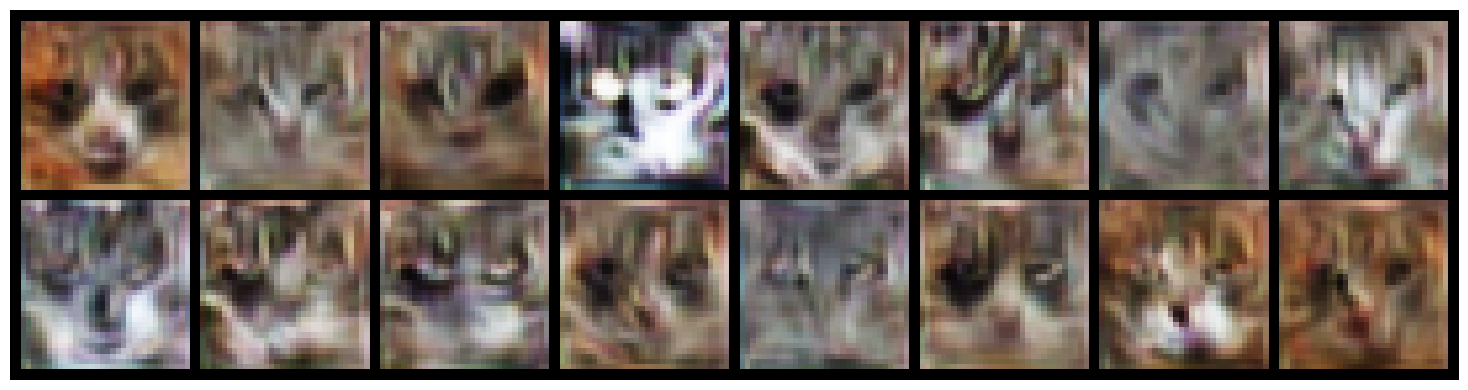

D_loss: 1.1895  G_loss: 0.9124  D(x): 0.180  D(G(z)): -0.289  Info_loss: 0.0011:  40%|███▉      | 1999/5000 [02:16<04:13, 11.82it/s]

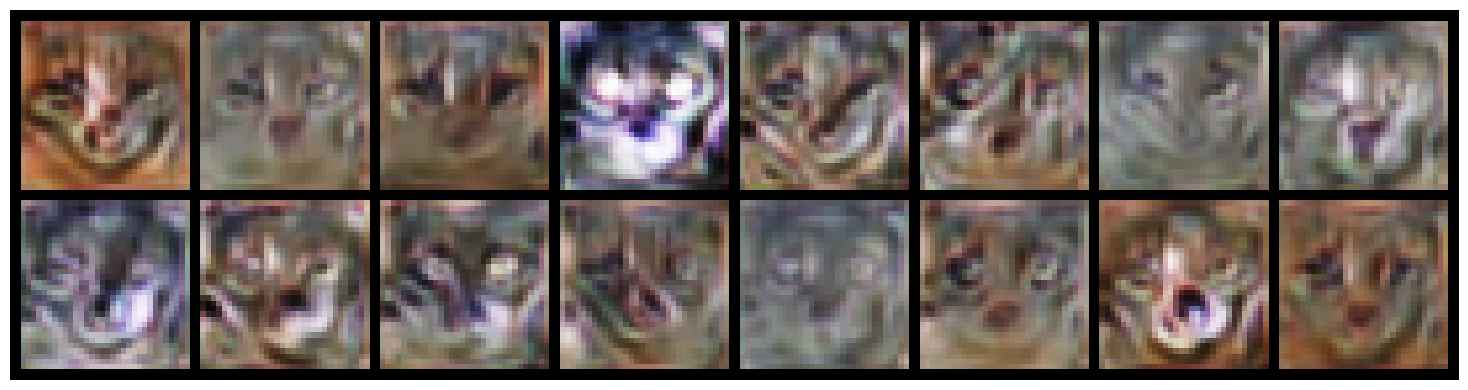

D_loss: 1.3100  G_loss: 0.7992  D(x): 0.171  D(G(z)): -0.039  Info_loss: 0.0009:  44%|████▍     | 2199/5000 [02:29<03:05, 15.11it/s]

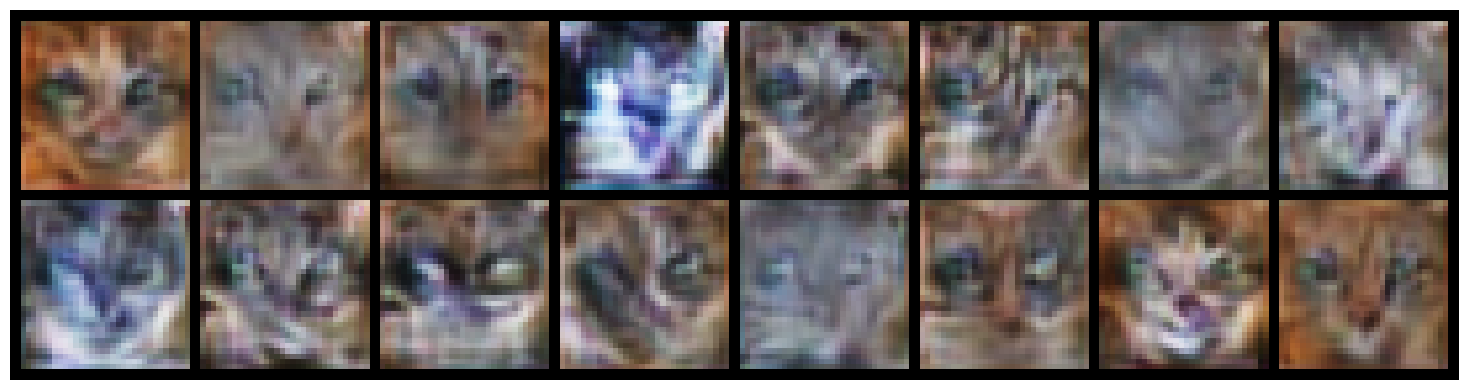

D_loss: 1.3248  G_loss: 0.9046  D(x): -0.089  D(G(z)): -0.254  Info_loss: 0.0012:  48%|████▊     | 2399/5000 [02:46<02:42, 16.04it/s]

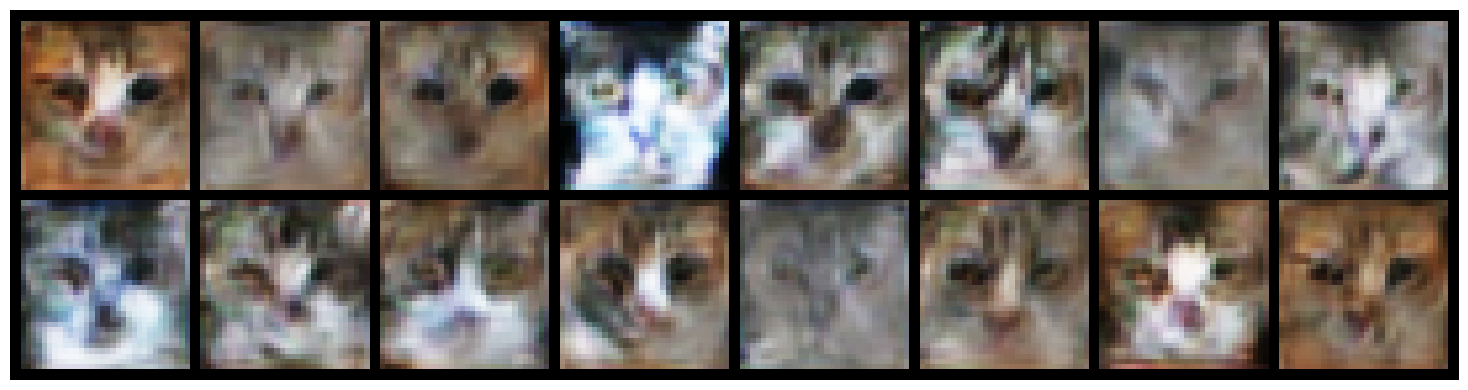

D_loss: 1.3660  G_loss: 0.8193  D(x): 0.061  D(G(z)): -0.025  Info_loss: 0.0009:  52%|█████▏    | 2599/5000 [03:00<02:26, 16.41it/s]

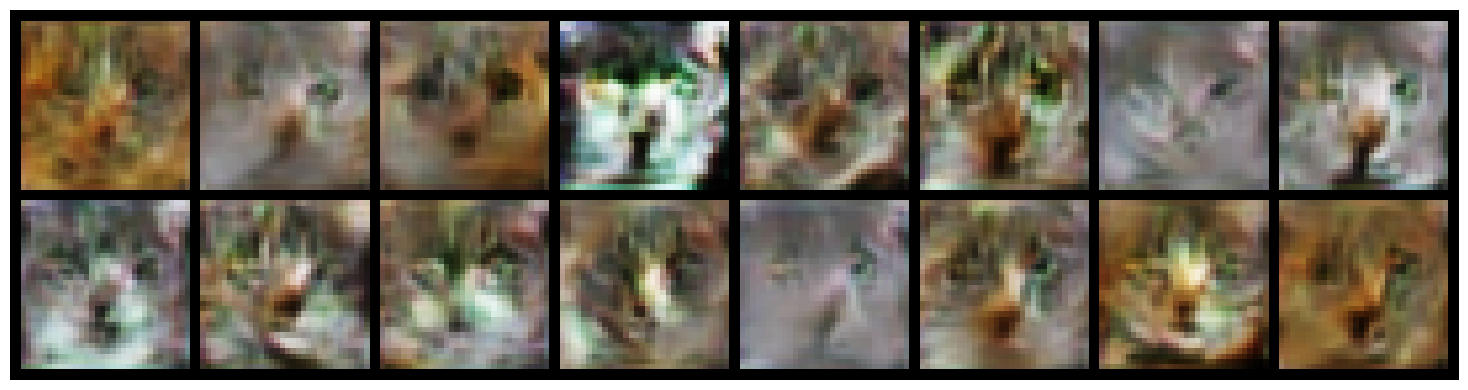

D_loss: 1.2121  G_loss: 0.8615  D(x): 0.234  D(G(z)): -0.177  Info_loss: 0.0009:  56%|█████▌    | 2799/5000 [03:13<02:13, 16.44it/s]

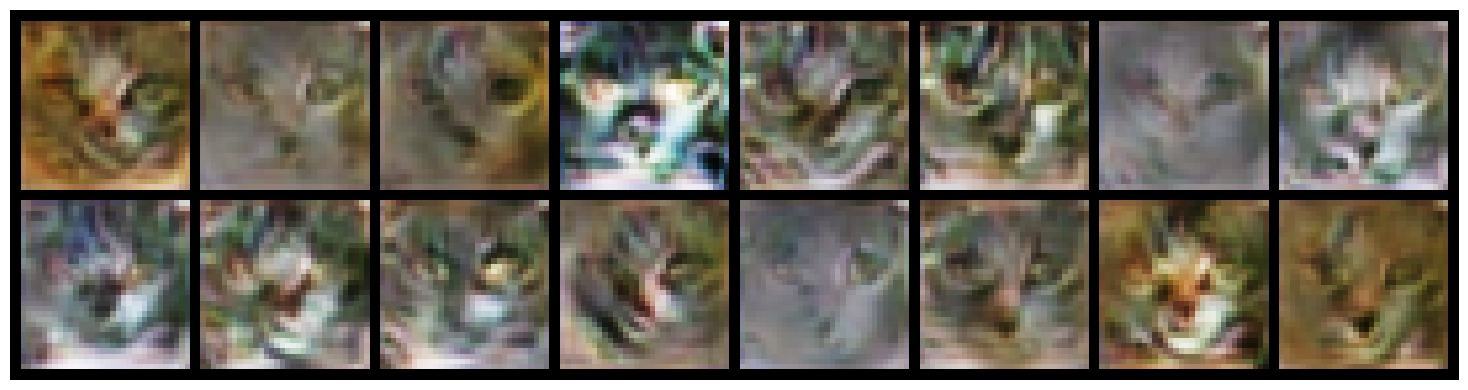

D_loss: 1.2478  G_loss: 0.8096  D(x): 0.235  D(G(z)): -0.097  Info_loss: 0.0007:  60%|█████▉    | 2999/5000 [03:27<02:03, 16.14it/s]

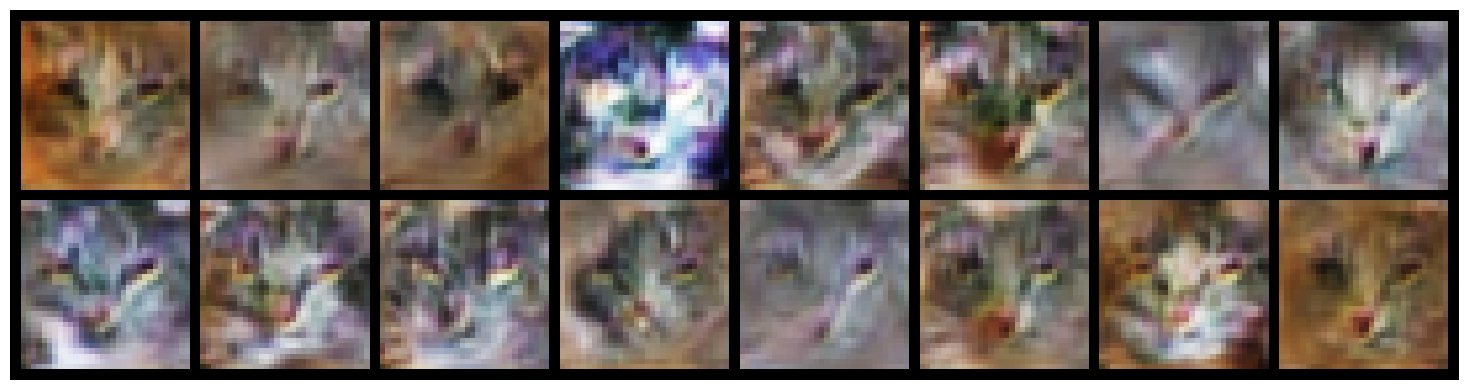

D_loss: 1.2408  G_loss: 0.8832  D(x): 0.137  D(G(z)): -0.213  Info_loss: 0.0007:  64%|██████▍   | 3199/5000 [03:40<01:54, 15.70it/s]

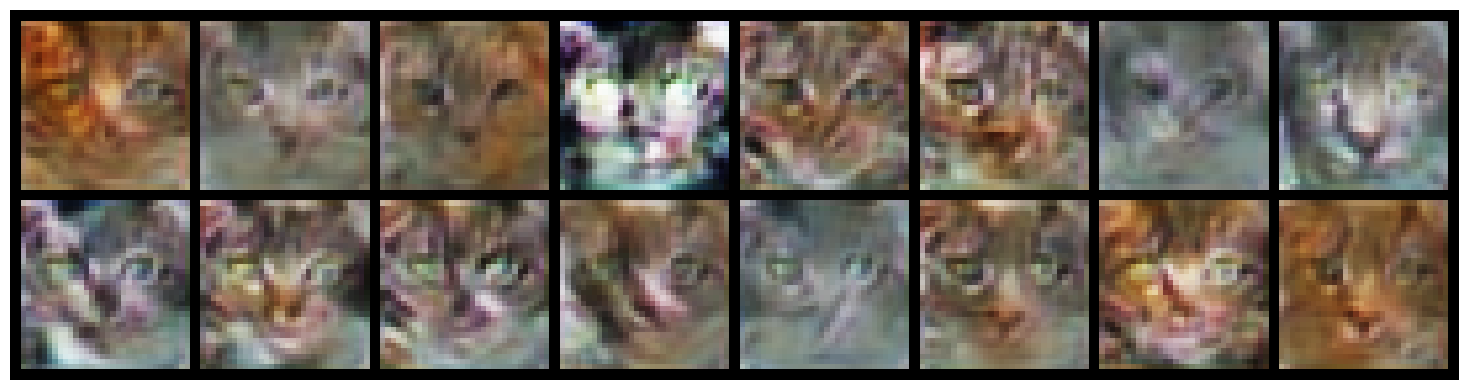

D_loss: 1.2350  G_loss: 0.8171  D(x): 0.139  D(G(z)): -0.221  Info_loss: 0.0009:  68%|██████▊   | 3399/5000 [03:54<01:38, 16.24it/s]

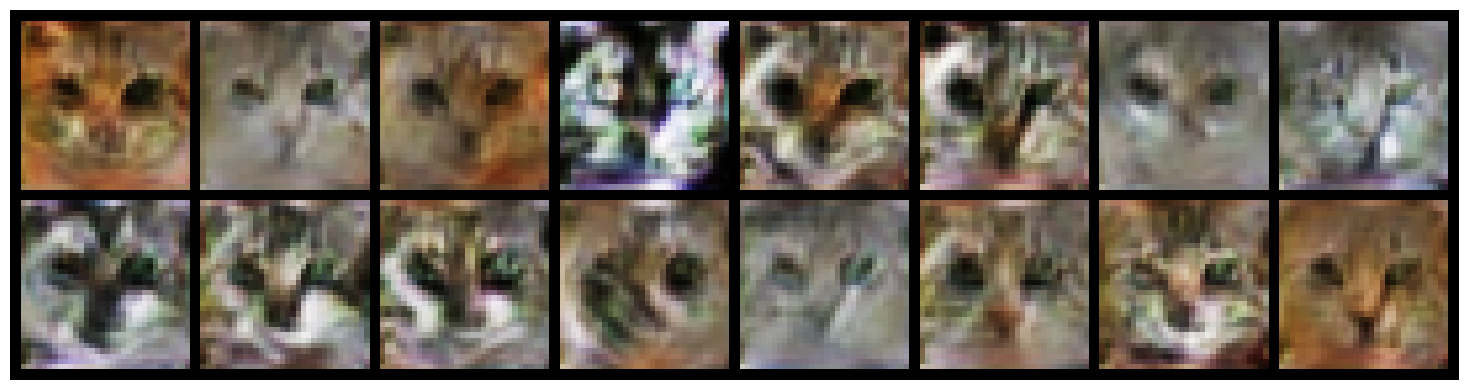

D_loss: 1.2346  G_loss: 0.8173  D(x): 0.221  D(G(z)): -0.140  Info_loss: 0.0013:  72%|███████▏  | 3599/5000 [04:10<01:28, 15.75it/s]

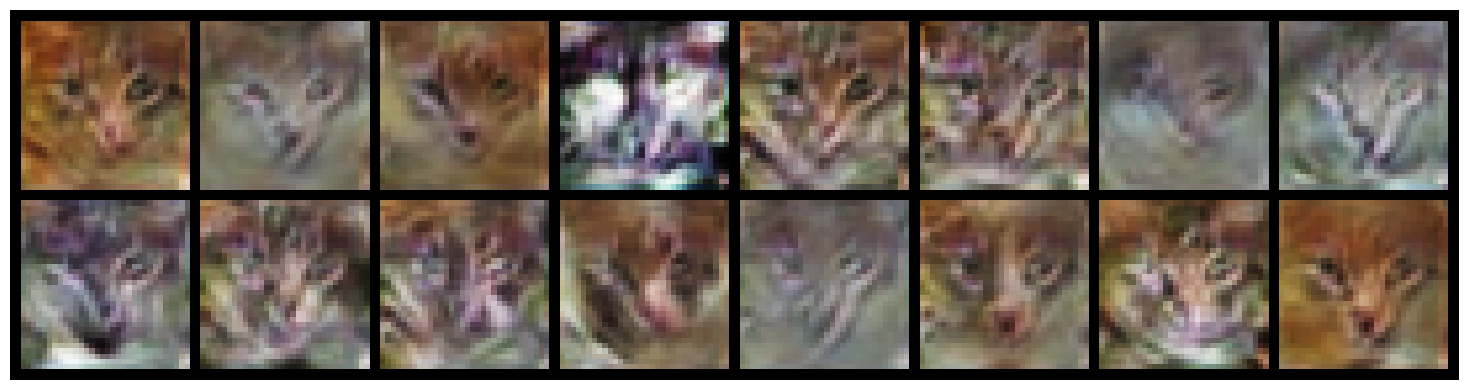

D_loss: 1.3448  G_loss: 0.8515  D(x): 0.076  D(G(z)): -0.078  Info_loss: 0.0007:  76%|███████▌  | 3799/5000 [04:24<01:36, 12.42it/s]

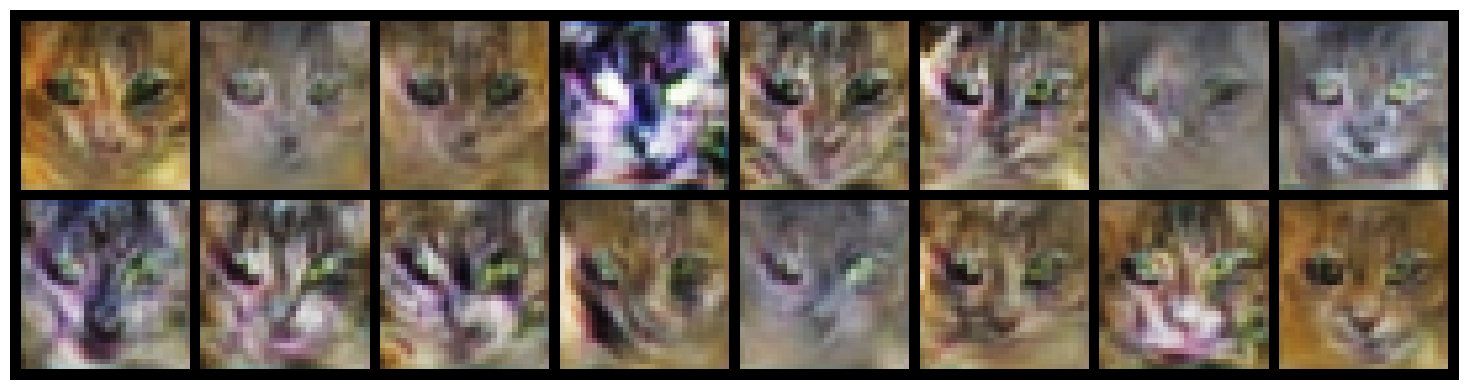

D_loss: 1.2777  G_loss: 0.8257  D(x): 0.079  D(G(z)): -0.180  Info_loss: 0.0005:  80%|███████▉  | 3999/5000 [04:38<01:20, 12.49it/s] 

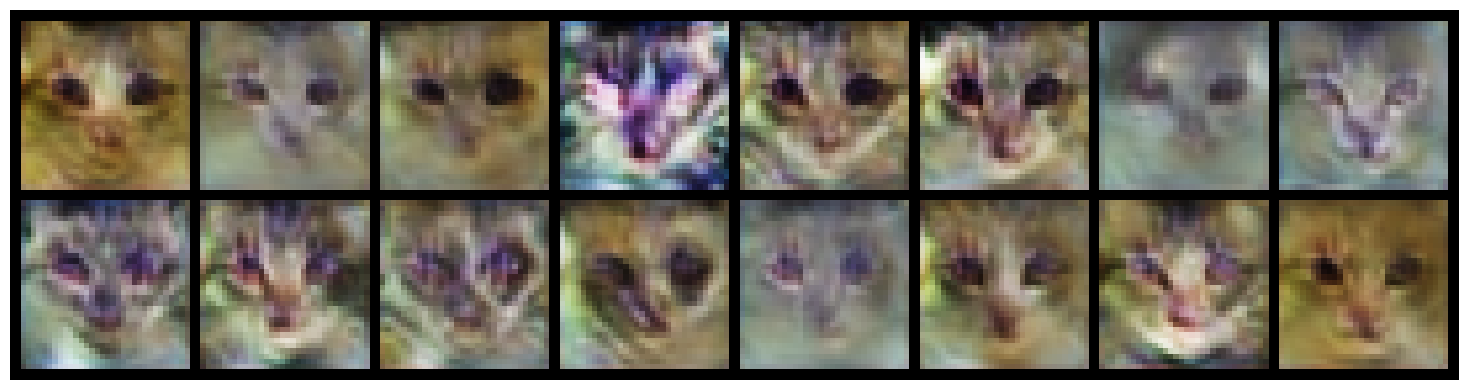

D_loss: 1.1410  G_loss: 0.8653  D(x): 0.348  D(G(z)): -0.234  Info_loss: 0.0007:  84%|████████▍ | 4199/5000 [04:52<01:01, 13.03it/s]

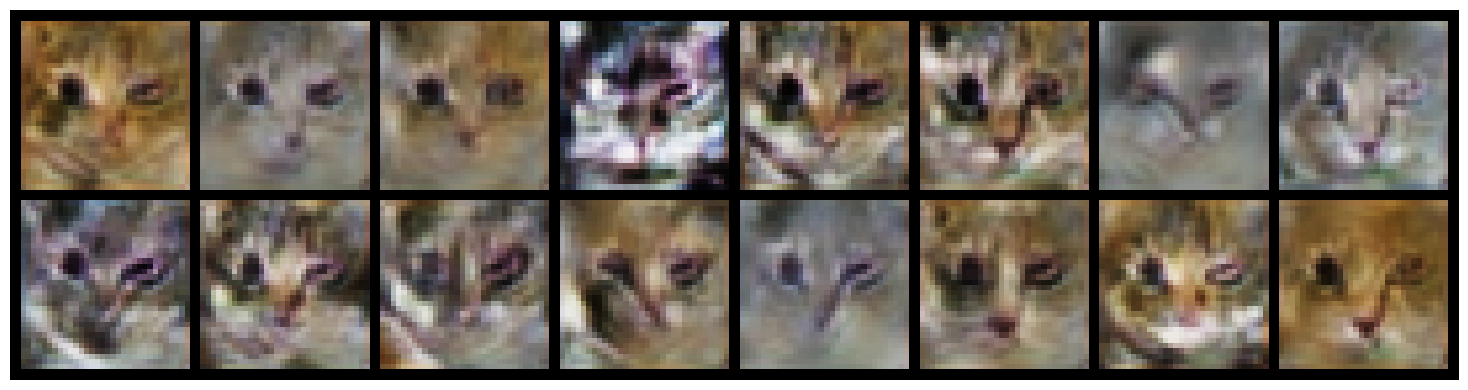

D_loss: 1.2619  G_loss: 0.8778  D(x): 0.336  D(G(z)): -0.027  Info_loss: 0.0007:  88%|████████▊ | 4399/5000 [05:05<00:37, 15.90it/s]

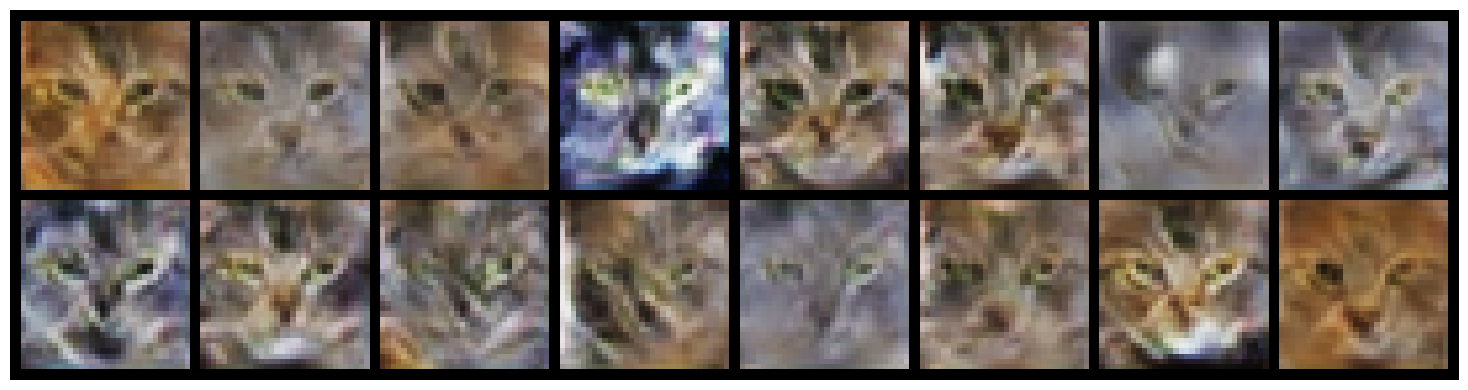

D_loss: 1.1547  G_loss: 0.9194  D(x): 0.257  D(G(z)): -0.313  Info_loss: 0.0008:  92%|█████████▏| 4599/5000 [05:19<00:24, 16.42it/s]

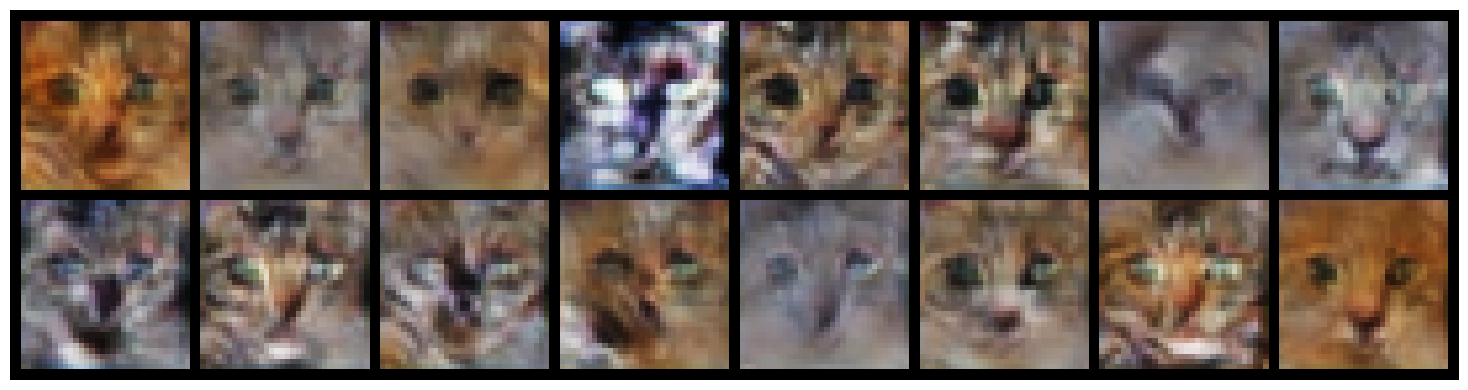

D_loss: 1.2450  G_loss: 0.9286  D(x): 0.189  D(G(z)): -0.162  Info_loss: 0.0005:  96%|█████████▌| 4799/5000 [05:32<00:12, 16.33it/s]

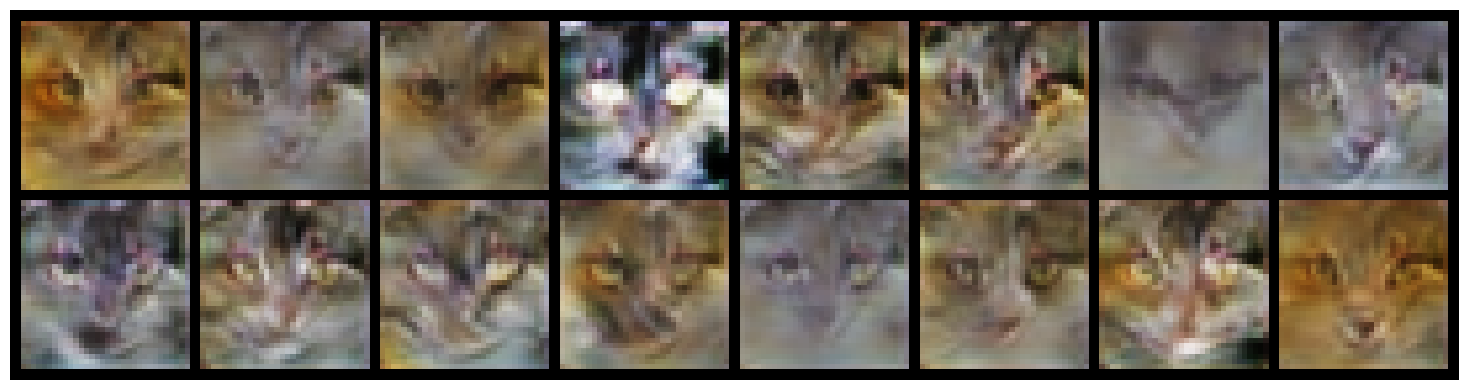

D_loss: 1.2321  G_loss: 0.9276  D(x): 0.222  D(G(z)): -0.185  Info_loss: 0.0006: 100%|█████████▉| 4999/5000 [05:46<00:00, 15.18it/s]

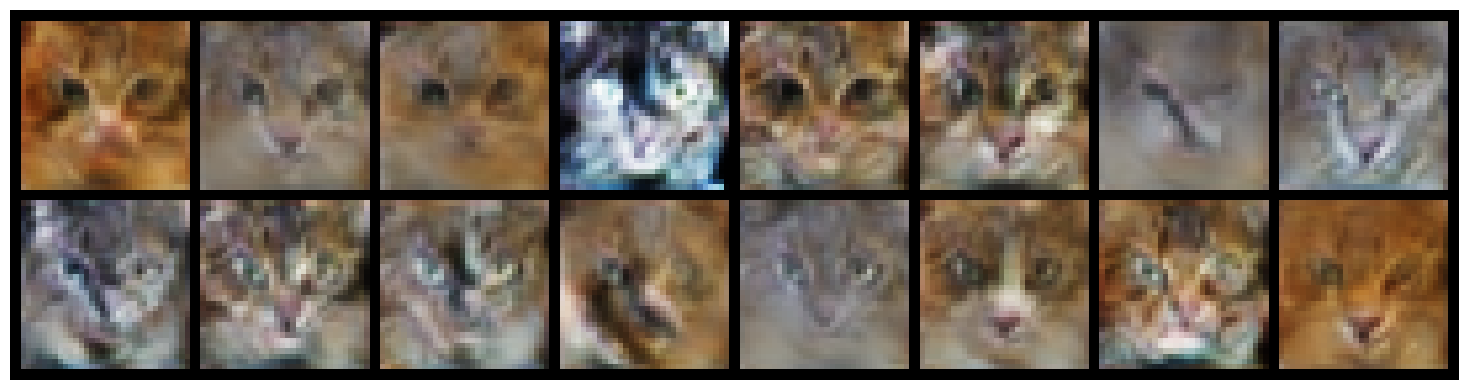

D_loss: 1.2321  G_loss: 0.9276  D(x): 0.222  D(G(z)): -0.185  Info_loss: 0.0006: 100%|██████████| 5000/5000 [05:46<00:00, 14.43it/s]


In [15]:
########## Train ##########

fixed_z_generator = torch.Generator(device=device).manual_seed(42)
fixed_z = torch.randn(16, latent_size, generator=fixed_z_generator, device=device) # for eval
fixed_label = to_onehot(torch.zeros(16, device=device, dtype=torch.long), class_size)
fixed_code = torch.zeros(16, code_size, device=device)

real_targets = torch.ones(batch_size, 1, device=device)  # (b, 1)
fake_targets = torch.zeros(batch_size, 1, device=device) # (b, 1)

pbar = tqdm(range(start_step, total_step), desc="InfoGAN")

for step in pbar:
    real_images = next(train_loader).to(device)


    ########## D Train ##########
    z = torch.randn(batch_size, latent_size, device=device)
    random_labels = to_onehot(torch.randint(0, class_size, (batch_size, ), device=device), class_size)
    random_codes = torch.empty(batch_size, code_size, device=device).uniform_(-1, 1)

    with torch.no_grad():
        fake_images = generator(z, random_labels, random_codes)

    d_real, _, _ = discriminator(real_images)
    d_fake, _, _ = discriminator(fake_images)
    real_adv_loss = adversarial_criterion(d_real, real_targets)
    fake_adv_loss = adversarial_criterion(d_fake, fake_targets)

    loss_D = real_adv_loss + fake_adv_loss

    optimizer_D.zero_grad()
    loss_D.backward()
    optimizer_D.step()


    ########## G Train ##########
    z = torch.randn(batch_size, latent_size, device=device)
    random_labels = to_onehot(torch.randint(0, class_size, (batch_size, ), device=device), class_size)
    random_codes = torch.empty(batch_size, code_size, device=device).uniform_(-1, 1)

    fake_images = generator(z, random_labels, random_codes)
    d_fake_g, _, _ = discriminator(fake_images)
    loss_G = adversarial_criterion(d_fake_g, real_targets)

    optimizer_G.zero_grad()
    loss_G.backward()
    optimizer_G.step()


    ########## Info Train ##########
    z = torch.randn(batch_size, latent_size, device=device)
    random_labels = to_onehot(torch.randint(0, class_size, (batch_size, ), device=device), class_size)
    random_codes = torch.empty(batch_size, code_size, device=device).uniform_(-1, 1)

    fake_images = generator(z, random_labels, random_codes)
    _, d_fake_label, d_fake_letent = discriminator(fake_images)

    categorical_loss = categorical_criterion(d_fake_label, random_labels)
    continuous_loss = continuous_criterion(d_fake_letent, random_codes)

    loss_info = lambda_categorical * categorical_loss + lambda_continuous * continuous_loss

    optimizer_info.zero_grad()
    loss_info.backward()
    optimizer_info.step()

    ########## Log ##########

    if (step + 1) % PRINT_INTERVAL == 0:
        pbar.set_description(
            f"D_loss: {loss_D.item():.4f}  G_loss: {loss_G.item():.4f}  "
            f"D(x): {d_real.mean().item():.3f}  D(G(z)): {d_fake.mean().item():.3f}  "
            f"Info_loss: {loss_info.mean().item():.4f}"
        )

    if (step + 1) % SAMPLE_INTERVAL == 0:
        visualize_sample(fixed_z, fixed_label, fixed_code, step + 1)

    if (step + 1) % CHECKPOINT_INTERVAL == 0:
        save_checkpoint(step + 1)